In [ ]:
#This file will be used to write the inference metrics obtained from footnet_inference.py
import sys
sys.path.append("/Users/abhinavarora/Desktop/CadenceCV/ml/src/inference")
from footnet_inference import frame_to_pred_dict, strikefoot_frames, frame_count, duration, right_hip_arr, left_hip_arr
import numpy as np
import scipy.signal

In [ ]:
#Clauclating the average time in air per gait cycle and average time in ground contact
def calculate_metrics():
    #Grouping pairs of 1s and 0s from the frame_to_pred_dict to obtain a gait cycle
    frame_preds = []
    for frame in frame_to_pred_dict:
        frame_preds.append(frame_to_pred_dict[frame])

    #(i+1)th - ith entry
    diff = np.diff(frame_preds)
    #contact:1, non-contact: 0. 
    #So, non_contact AFTER contact = 0 - 1 = -1 (takeoff frame)
    takeoff_frames = np.where(diff == -1)[0]
    #So, contact AFTER non-contact = 1 - 0 = 1 (Strikefoot frame)
    landing_frames = np.where(diff == 1)[0]

    flight_times = []
    gct_times = []
    for takeoff in takeoff_frames:
        #Find the next landing after this takeoff. Finding all landings initially to check if there even is a landing 
        #after the take off frames.
        next_landings = landing_frames[landing_frames > takeoff]
        if len(next_landings) > 0:
            next_landing = next_landings[0]
            flight_times.append(next_landing - takeoff)
    
    for landing in landing_frames:
        next_takeoffs = takeoff_frames[takeoff_frames>landing]
        if len(next_takeoffs) > 0:
            next_takeoff = next_takeoff[0]
            gct_times.append(next_takeoff - landing)

    #Divide by frame count to obtain metrics in seconds
    average_flight_time = (np.mean(flight_times) if flight_times else 0)/frame_count
    average_gct = (np.mean(gct_times) if gct_times else 0)/frame_count

    #Cadence is the steps per second
    cadence = len(strikefoot_frames)/duration

    #Vertical oscillation: 
    # 1) Calculate the hip's mean coordinate (mean of right and left hip coordinates) over all frames
    # 2) Apply the Savitz-Golay smoothing filter (finetune the window size)
    # 3) Separate out the smoothed array based on each gait cycle: (continuous pairs of 0s and 1s)
    # 4) Obtain the vertical difference between each peak and trough (since pixel coordinates go downward)

    mean_hip_arr_coords = []
    for i in range(len(frame_preds)):
        if i < len(right_hip_arr) and i < len(left_hip_arr):
            mean_hip_arr_coords[i] = np.mean([right_hip_arr[i], left_hip_arr[i]])
    
    #The window length is the number of coefficients for smoothing
    #The poly order is the degree of the filtering polynomial
    #Finetune these accordingly
    mean_hip_arr_coords = scipy.signal.savgol_filter(mean_hip_arr_coords, window_length=4, polyorder=3)

    #Extracting gait cycles: Pictorial explanation in the next cell:
    changes = np.where(np.diff(frame_preds) == -1) + 1
    #Pairs of -1 is one gait cycle
    cycles = []
    cycle = []
    for i in changes:
        cycle.append(i)
        if len(cycle) == 2:
            cycles.append(cycle.copy())
            cycle = []
    
    oscillations = []
    for c in cycles:
        start = c[0]
        end = c[1]
        peak = max(mean_hip_arr_coords[start:end])
        trough = min(mean_hip_arr_coords[start:end])
        oscillations.append(peak - trough)
    
    avg_oscillation = np.mean(oscillations) if oscillations else 0
        





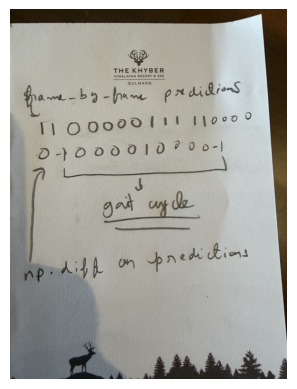

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
imgplot = plt.imread("/Users/abhinavarora/Desktop/CadenceCV/gait_cycle_extraction.jpg")
#Rotating the initial image to be upright
rotated_image = ndimage.rotate(imgplot, -90, reshape=True)
plt.axis('off')
imgplot = plt.imshow(rotated_image)
